# Multi-LLM SAC Study — Clean Implementation

Five fully independent cases, each runnable on its own:

| # | Case | Model |
|---|------|-------|
| 0 | **Baseline** | No SAC (plain chunk embedding) |
| 1 | **SAC — Llama 3.1-8B** | `llama-3.1-8b-instant` via Groq |
| 2 | **SAC — Qwen 3-32B** | `qwen/qwen3-32b` via Groq (COT model → strips `<think>`) |
| 3 | **SAC — DeepSeek-R1** | `deepseek-r1-distill-llama-70b` via Groq (COT model → strips `<think>`) |
| 4 | **SAC — Gemini 1.5 Flash** | Google Gemini via `google-generativeai` |

**Structure per case:**
1. Install / imports
2. Set API keys
3. Load documents & queries
4. FAISS patch
5. Define `SummaryGenerator` (model-specific)
6. Build retriever & index
7. Evaluate
8. Print results

> Run **Setup (Shared)** once, then run whichever case(s) you want.

## ── SETUP (run once) ──────────────────────────────────────────

In [1]:
# Install dependencies
!pip install groq google-generativeai faiss-cpu sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.3 MB/s eta 0:00:00


In [2]:
# Upload corpus.zip and benchmarks.zip
from google.colab import files
import zipfile, os, json

print("Upload corpus.zip")
uploaded = files.upload()
for fn in uploaded:
    with zipfile.ZipFile(fn) as z:
        z.extractall('.')
    print(f"Extracted {fn}")

print("\nUpload benchmarks.zip (or the individual .json files)")
uploaded = files.upload()
for fn in uploaded:
    if fn.endswith('.zip'):
        with zipfile.ZipFile(fn) as z:
            z.extractall('.')
        print(f"Extracted {fn}")

print("\nFiles in working directory:")
!ls *.json 2>/dev/null; ls contractnli/ | head -3

Upload corpus.zip


Saving corpus.zip to corpus.zip
Extracted corpus.zip

Upload benchmarks.zip (or the individual .json files)


Saving benchmarks.zip to benchmarks.zip
Extracted benchmarks.zip

Files in working directory:
contractnli.json  cuad.json  maud.json	privacy_qa.json
01_Bosch-Automotive-Service-Solutions-Mutual-Non-Disclosure-Agreement-7-12-17.txt
12032018_NDA_The%20Munt_EN.txt
5-NSK-Confidentiality-Agreement-for-Suppliers.txt


In [3]:
# ── Shared data loading (documents + queries) ──────────────────
import os, json
from rag_sac_implementation import Document, Query, RAGRetriever, RAGEvaluator

DATASET   = 'contractnli'
BENCH_FILE = 'contractnli.json'

# Load documents
documents = []
for filename in os.listdir(DATASET):
    fp = os.path.join(DATASET, filename)
    if not os.path.isfile(fp) or not filename.endswith('.txt'):
        continue
    with open(fp, encoding='utf-8') as f:
        content = f.read()
    documents.append(Document(
        doc_id=filename.replace('.txt', ''),
        filename=filename,
        content=content,
        doc_type='contractnli'
    ))
print(f"Loaded {len(documents)} documents")

# Load queries
with open(BENCH_FILE) as f:
    bench = json.load(f)
queries = []
for item in bench['tests']:
    if 'snippets' not in item or not item['snippets']:
        continue
    s = item['snippets'][0]
    doc_id = s['file_path'].split('/')[-1].replace('.txt', '')
    start, end = s['span']
    queries.append(Query(
        query_id=str(len(queries)),
        query_text=item['query'],
        ground_truth_doc_id=doc_id,
        ground_truth_start=start,
        ground_truth_end=end
    ))
print(f"Loaded {len(queries)} queries")

TOP_K_VALUES = [1, 2, 4, 8, 16]
evaluator    = RAGEvaluator()
all_results  = {}

Loaded 95 documents
Loaded 977 queries


In [4]:
# ── FAISS patch (fixes contiguous-array bug on Colab) ──────────
import numpy as np, faiss
_orig_norm = faiss.normalize_L2
def _fixed_norm(x):
    return _orig_norm(np.ascontiguousarray(x.astype('float32')))
faiss.normalize_L2 = _fixed_norm
print("FAISS patch applied")

FAISS patch applied


In [ ]:
# ── API keys ───────────────────────────────────────────────────
import os
os.environ["GROQ_API_KEY"]   = ""
os.environ["GEMINI_API_KEY"] = ""
print("Keys set")

Keys set


---
## ── CASE 0 · Baseline (no SAC) ──────────────────────────────

In [6]:
print("="*60)
print("CASE 0 — Baseline (no SAC)")
print("="*60)

ret_baseline = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=False,
    chunk_size=500,
)
ret_baseline.index_documents(documents)

results_baseline = evaluator.evaluate_dataset(
    queries, ret_baseline, top_k_values=TOP_K_VALUES
)
all_results["Baseline"] = results_baseline
print("Finished: Baseline")

CASE 0 — Baseline (no SAC)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexing 95 documents...
Chunking documents...
Created 3078 chunks
Generating embeddings...


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 80.45%
  Precision: 0.0257
  Recall: 0.0355

Evaluating with top_k=2...
  DRM: 84.03%
  Precision: 0.0305
  Recall: 0.0562

Evaluating with top_k=4...
  DRM: 87.56%
  Precision: 0.0385
  Recall: 0.0819

Evaluating with top_k=8...
  DRM: 90.88%
  Precision: 0.0509
  Recall: 0.1077

Evaluating with top_k=16...
  DRM: 93.51%
  Precision: 0.0592
  Recall: 0.1362
Finished: Baseline


---
## ── CASE 1 · SAC — Llama 3.1-8B (Groq) ─────────────────────

In [13]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class LlamaSummaryGenerator:
    """
    Llama 3.1-8B-instant via Groq.
    Standard chat model — no CoT, no <think> stripping needed.
    """
    MODEL = "llama-3.3-70b-versatile" #"llama-3.1-8b-instant"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary, no preamble.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.client      = Groq(api_key=os.environ["GROQ_API_KEY"])

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=120,
                    stop=["\n"],
                )
                s = r.choices[0].message.content.strip().strip('"\'')
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "rate_limit" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt
                    print(f"  Rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    # Aliases expected by RAGRetriever
    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("LlamaSummaryGenerator defined")

LlamaSummaryGenerator defined


In [8]:
print("="*60)
print("CASE 1 — SAC with Llama 3.1-8B (Groq)")
print("="*60)

SUMMARY_LENGTH = 150

ret_llama = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_llama.summary_generator = LlamaSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_llama.index_documents(documents)

results_llama = evaluator.evaluate_dataset(
    queries, ret_llama, top_k_values=TOP_K_VALUES
)
all_results["Llama 3.1-8B (Groq)"] = results_llama
print("Finished: Llama")

CASE 1 — SAC with Llama 3.1-8B (Groq)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 95 documents...
Generating document summaries...
  [Aspiegel_NDA_template] Aspiegel Limited and Company agree to maintain confidentiality of disclosed information for the specified purpose, governed by Irish law.
  [EFCAConfidentialityAgreement] EFCA Pty Ltd (receiving party) and disclosing party agree to maintain confidentiality and protect trade secrets, with obligations including secure han
  [HNBA-2017-18-Confidentiality-Agreement] HNBA and Board Member agree to confidentiality regarding HNBA business and personal information, governed by applicable law.
  [nda_gtl_inria] Inria and Organization agree to a 1-year non-disclosure of proprietary data for research purposes, governed by French law.
  [NDA-Seeed] Seeed Development Limited and Customer agree to a Non-Disclosure Agreement, exchanging confidential information while safeguarding it through mutual o
  [Mutual-Non-Disclosure-Agreement-Inventor] Product Development Experts, Inc. and Inventor agree to mutual non-disclosu

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 38.49%
  Precision: 0.1053
  Recall: 0.1334

Evaluating with top_k=2...
  DRM: 40.02%
  Precision: 0.1046
  Recall: 0.2116

Evaluating with top_k=4...
  DRM: 40.84%
  Precision: 0.0960
  Recall: 0.3311

Evaluating with top_k=8...
  DRM: 42.63%
  Precision: 0.0756
  Recall: 0.4481

Evaluating with top_k=16...
  DRM: 47.17%
  Precision: 0.0605
  Recall: 0.5651
Finished: Llama


---
## ── CASE 2 · SAC — Qwen 3-32B (Groq, CoT) ─────────────────

In [9]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class QwenSummaryGenerator:
    """
    Qwen3-32B via Groq.
    This is a reasoning/CoT model: it prefixes its answer with a
    <think>...</think> block.  We strip everything up to and including
    </think> before returning the summary.

    We also pass  include_reasoning=False  to suppress the CoT in the
    response payload (Groq supports this flag for Qwen3).
    """
    MODEL = "qwen/qwen3-32b"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary, no preamble, no explanation.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.client      = Groq(api_key=os.environ["GROQ_API_KEY"])

    @staticmethod
    def _strip_think(text: str) -> str:
        """Remove <think>...</think> block (may span multiple lines)."""
        # Remove entire <think> block
        text = re.sub(r'<think>[\s\S]*?</think>', '', text, flags=re.IGNORECASE)
        # Also strip any bare <think> prefix that appears without a closing tag
        text = re.sub(r'^\s*<think>.*', '', text, flags=re.IGNORECASE | re.MULTILINE)
        return text.strip()

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=600,   # extra room for the <think> block
                    # Tell Groq not to return the reasoning tokens in the payload:
                    extra_body={"include_reasoning": False},
                )
                raw = r.choices[0].message.content or ""
                s   = self._strip_think(raw)
                # Take only the first non-empty line
                for line in s.splitlines():
                    line = line.strip().strip('"\'')
                    if line:
                        s = line
                        break
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "rate_limit" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt
                    print(f"  Rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("QwenSummaryGenerator defined")

QwenSummaryGenerator defined


In [10]:
print("="*60)
print("CASE 2 — SAC with Qwen3-32B (Groq, CoT stripping)")
print("="*60)

SUMMARY_LENGTH = 150

ret_qwen = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_qwen.summary_generator = QwenSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_qwen.index_documents(documents)

results_qwen = evaluator.evaluate_dataset(
    queries, ret_qwen, top_k_values=TOP_K_VALUES
)
all_results["Qwen3-32B (Groq)"] = results_qwen
print("Finished: Qwen")

CASE 2 — SAC with Qwen3-32B (Groq, CoT stripping)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 95 documents...
Generating document summaries...
  [Aspiegel_NDA_template] Aspiegel Limited and [Company] enter a Confidentiality and Non-D
  [EFCAConfidentialityAgreement] 
  [HNBA-2017-18-Confidentiality-Agreement] 
  [nda_gtl_inria] Inria and User enter NDA for GTL data use in research; requires citations, no third-party distribution; governed by French law.
  [NDA-Seeed] Customer and Seeed Development Limited (Hong Kong) enter NDA obligating non-disclosure of confidential info; governed by Hong Kong law.
  [Mutual-Non-Disclosure-Agreement-Inventor] Product Development Experts, Inc. and Inventor enter Mutual Non-Disclosure Agreement to protect confidential info from use/disclosure.
  [RROI_Confidentiality_Agreement_Final] Red River Oil Inc. and Recipient enter Confidentiality Agreement to protect Evaluation Material; governed by Alberta law.
  [oceaneering-non-disclosure-agreement] Oceaneering and Recipient enter a Vendor/Supplier NDA requiring confidentiality of Oceaneerin

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 53.12%
  Precision: 0.0690
  Recall: 0.0889

Evaluating with top_k=2...
  DRM: 55.73%
  Precision: 0.0720
  Recall: 0.1446

Evaluating with top_k=4...
  DRM: 57.34%
  Precision: 0.0708
  Recall: 0.2297

Evaluating with top_k=8...
  DRM: 59.70%
  Precision: 0.0671
  Recall: 0.3253

Evaluating with top_k=16...
  DRM: 63.17%
  Precision: 0.0653
  Recall: 0.4268
Finished: Qwen


---
## ── CASE 3 · SAC — DeepSeek-R1 (Groq, CoT) ─────────────────

In [11]:
import os, time, re
from groq import Groq
from rag_sac_implementation import Document

class DeepSeekSummaryGenerator:
    """
    DeepSeek-R1-Distill-Llama-70B via Groq.
    Like Qwen3, this is a CoT/reasoning model that wraps its answer in
    <think>...</think>.  We strip the block before returning.

    Available model IDs on Groq (check https://console.groq.com/docs/models):
      - deepseek-r1-distill-llama-70b   (recommended — available as of 2025)
      - deepseek-r1-distill-qwen-32b
    The 8B distillation (deepseek-r1-distill-llama-8b) was removed from Groq.
    """
    MODEL = "deepseek-r1-distill-llama-70b"

    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary after your reasoning, no extra text.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        self.client      = Groq(api_key=os.environ["GROQ_API_KEY"])

    @staticmethod
    def _strip_think(text: str) -> str:
        """Remove <think>...</think> block (may span multiple lines)."""
        text = re.sub(r'<think>[\s\S]*?</think>', '', text, flags=re.IGNORECASE)
        text = re.sub(r'^\s*<think>.*', '', text, flags=re.IGNORECASE | re.MULTILINE)
        return text.strip()

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        system  = self.SYS.format(n=self.n)
        user    = self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.client.chat.completions.create(
                    model=self.MODEL,
                    messages=[{"role": "system", "content": system},
                               {"role": "user",   "content": user}],
                    temperature=0.2,
                    max_tokens=1024,  # DeepSeek-R1 needs room for its <think> block
                )
                raw = r.choices[0].message.content or ""
                s   = self._strip_think(raw)
                # Take only the first non-empty line after stripping
                for line in s.splitlines():
                    line = line.strip().strip('"\'')
                    if line:
                        s = line
                        break
                s = s[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "rate_limit" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt
                    print(f"  Rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Groq error: {e}")
                    break

        return self._fallback(document)

    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("DeepSeekSummaryGenerator defined")

DeepSeekSummaryGenerator defined


In [14]:
print("="*60)
print("CASE 3 — SAC with DeepSeek-R1-70B (Groq, CoT stripping)")
print("="*60)

SUMMARY_LENGTH = 150

ret_deepseek = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_deepseek.summary_generator = LlamaSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_deepseek.index_documents(documents)

results_deepseek = evaluator.evaluate_dataset(
    queries, ret_deepseek, top_k_values=TOP_K_VALUES
)
all_results["Llama-3.3-70b-versatile (Groq)"] = results_deepseek
print("Finished: DeepSeek")

CASE 3 — SAC with DeepSeek-R1-70B (Groq, CoT stripping)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 95 documents...
Generating document summaries...
  [Aspiegel_NDA_template] Aspiegel and Company agree to confidentiality.
  [EFCAConfidentialityAgreement] Parties: Disclosing, EFCA; Type: NDA; Obligation: Confidentiality.
  [HNBA-2017-18-Confidentiality-Agreement] HNBA and Board Member agree to confidentiality.
  [nda_gtl_inria] Inria and User: non-disclosure for research use.
  [NDA-Seeed] Parties: Customer & Seeed; NDA; confidentiality obligation.
  [Mutual-Non-Disclosure-Agreement-Inventor] Parties: Product Development Experts, Inc. and Inventor; NDA governs confidential info exchange.
  [RROI_Confidentiality_Agreement_Final] Red River Oil and Recipient: Confidentiality Agreement, non-disclosure obligation.
  [oceaneering-non-disclosure-agreement] Oceaneering and Recipient: non-disclosure agreement, protect confidential info.
  [NDA-SqillerBetaTesters] Teqball and user agree to mutual non-disclosure of confidential info.
  [New_York_City_Bar_Association_Model_Form] Company 

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 46.16%
  Precision: 0.1023
  Recall: 0.1291

Evaluating with top_k=2...
  DRM: 47.59%
  Precision: 0.0922
  Recall: 0.1861

Evaluating with top_k=4...
  DRM: 49.54%
  Precision: 0.0804
  Recall: 0.2755

Evaluating with top_k=8...
  DRM: 51.64%
  Precision: 0.0698
  Recall: 0.3773

Evaluating with top_k=16...
  DRM: 56.29%
  Precision: 0.0616
  Recall: 0.4732
Finished: DeepSeek


---
## ── CASE 4 · SAC — Gemini 1.5 Flash ────────────────────────

In [15]:
import os, time, re
import google.generativeai as genai
from rag_sac_implementation import Document

class GeminiSummaryGenerator:
    """
    Gemini 1.5 Flash via google-generativeai.
    Standard generative model — no CoT stripping needed.
    """
    SYS = ("You are a legal document summarizer. "
           "Produce ONE line under {n} characters. "
           "Include: parties, document type, key obligation, governing law. "
           "Output ONLY the summary, no preamble.")

    USR = ("Summarize this legal document in under {n} characters.\n"
           "Focus on: parties, purpose, key obligations.\n\n"
           "Document:\n{content}\n\nOne line only, under {n} characters:")

    def __init__(self, summary_length=150, max_retries=3, retry_delay=2.0):
        self.n           = summary_length
        self.max_retries = max_retries
        self.retry_delay = retry_delay
        genai.configure(api_key=os.environ["GEMINI_API_KEY"])
        self.model = genai.GenerativeModel("gemini-1.5-flash")

    def _fallback(self, document):
        sents = re.split(r'[.!?]+', document.content.strip())
        s = ' '.join(x.strip() for x in sents[:2] if x.strip())
        return s[:self.n].strip()

    def generate_summary(self, document):
        snippet = document.content[:3000]
        prompt  = self.SYS.format(n=self.n) + "\n\n" + self.USR.format(n=self.n, content=snippet)

        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.model.generate_content(
                    prompt,
                    generation_config={
                        "temperature":    0.2,
                        "max_output_tokens": 120,
                        "stop_sequences": ["\n"],
                    }
                )
                s = r.text.strip().strip('"\'')[:self.n]
                print(f"  [{document.doc_id[:40]}] {s}")
                return s
            except Exception as e:
                err = str(e)
                if "quota" in err.lower() or "429" in err:
                    wait = self.retry_delay * attempt
                    print(f"  Gemini rate limited — waiting {wait}s (attempt {attempt})")
                    time.sleep(wait)
                else:
                    print(f"  Gemini error: {e}")
                    break

        return self._fallback(document)

    def generate_generic_summary(self, doc): return self.generate_summary(doc)
    def generate_expert_summary(self, doc):  return self.generate_summary(doc)


print("GeminiSummaryGenerator defined")

GeminiSummaryGenerator defined


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [16]:
print("="*60)
print("CASE 4 — SAC with Gemini 1.5 Flash")
print("="*60)

SUMMARY_LENGTH = 150

ret_gemini = RAGRetriever(
    embedding_model_name="sentence-transformers/all-MiniLM-L6-v2",
    use_sac=True,
    summary_length=SUMMARY_LENGTH,
    chunk_size=500,
)
ret_gemini.summary_generator = GeminiSummaryGenerator(summary_length=SUMMARY_LENGTH)

ret_gemini.index_documents(documents)

results_gemini = evaluator.evaluate_dataset(
    queries, ret_gemini, top_k_values=TOP_K_VALUES
)
all_results["Gemini 1.5 Flash"] = results_gemini
print("Finished: Gemini")

CASE 4 — SAC with Gemini 1.5 Flash


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 95 documents...
Generating document summaries...


  Gemini error: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


...

  Gemini error: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


  Gemini error: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


  Gemini error: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.
Chunking documents...
Created 3078 chunks
Generating embeddings...


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Building FAISS index...
Indexing complete!

Evaluating with top_k=1...
  DRM: 60.18%
  Precision: 0.0796
  Recall: 0.1044

Evaluating with top_k=2...
  DRM: 62.79%
  Precision: 0.0771
  Recall: 0.1437

Evaluating with top_k=4...
  DRM: 65.30%
  Precision: 0.0798
  Recall: 0.2219

Evaluating with top_k=8...
  DRM: 68.03%
  Precision: 0.0792
  Recall: 0.3060

Evaluating with top_k=16...
  DRM: 73.57%
  Precision: 0.0824
  Recall: 0.3824
Finished: Gemini


---
## ── RESULTS ─────────────────────────────────────────────────

In [17]:
# ── Full results table ─────────────────────────────────────────
TOP_K_VALUES = [1, 2, 4, 8, 16]
method_names = list(all_results.keys())

print("\n" + "="*100)
print("MULTI-LLM SAC STUDY  —  FULL RESULTS")
print("="*100)

for k in TOP_K_VALUES:
    print(f"\n{'='*100}")
    print(f"Top-K = {k}")
    print(f"{'-'*100}")
    print(f"{'Method':<36} {'DRM (%)':>10} {'Precision':>12} {'Recall':>12}")
    print(f"{'-'*100}")
    for name in method_names:
        r = all_results[name][k]
        print(f"{name:<36} {r['drm']:>9.2f}% {r['precision']:>12.4f} {r['recall']:>12.4f}")

print("\n" + "="*100)


MULTI-LLM SAC STUDY  —  FULL RESULTS

Top-K = 1
----------------------------------------------------------------------------------------------------
Method                                  DRM (%)    Precision       Recall
----------------------------------------------------------------------------------------------------
Baseline                                 80.45%       0.0257       0.0355
Llama 3.1-8B (Groq)                      38.49%       0.1053       0.1334
Qwen3-32B (Groq)                         53.12%       0.0690       0.0889
Llama-3.3-70b-versatile (Groq)           46.16%       0.1023       0.1291
Gemini 1.5 Flash                         60.18%       0.0796       0.1044

Top-K = 2
----------------------------------------------------------------------------------------------------
Method                                  DRM (%)    Precision       Recall
----------------------------------------------------------------------------------------------------
Baseline          

In [18]:
# ── Summary table at k=8 with delta vs Baseline ────────────────
print("\n" + "="*95)
print("FINAL SUMMARY TABLE  (k=8)")
print("="*95)
print(f"{'Method':<36} {'DRM':>8} {'Precision':>10} {'Recall':>10} {'DRM Δ vs Baseline':>22}")
print("-"*95)

base8 = all_results["Baseline"][8]
for name in method_names:
    r    = all_results[name][8]
    drop = base8["drm"] - r["drm"]
    ds   = f"{drop:+.2f} pp" if name != "Baseline" else "reference"
    print(f"{name:<36} {r['drm']:>7.2f}% {r['precision']:>10.4f} {r['recall']:>10.4f} {ds:>22}")

print("="*95)


FINAL SUMMARY TABLE  (k=8)
Method                                    DRM  Precision     Recall      DRM Δ vs Baseline
-----------------------------------------------------------------------------------------------
Baseline                               90.88%     0.0509     0.1077              reference
Llama 3.1-8B (Groq)                    42.63%     0.0756     0.4481              +48.25 pp
Qwen3-32B (Groq)                       59.70%     0.0671     0.3253              +31.18 pp
Llama-3.3-70b-versatile (Groq)         51.64%     0.0698     0.3773              +39.24 pp
Gemini 1.5 Flash                       68.03%     0.0792     0.3060              +22.85 pp


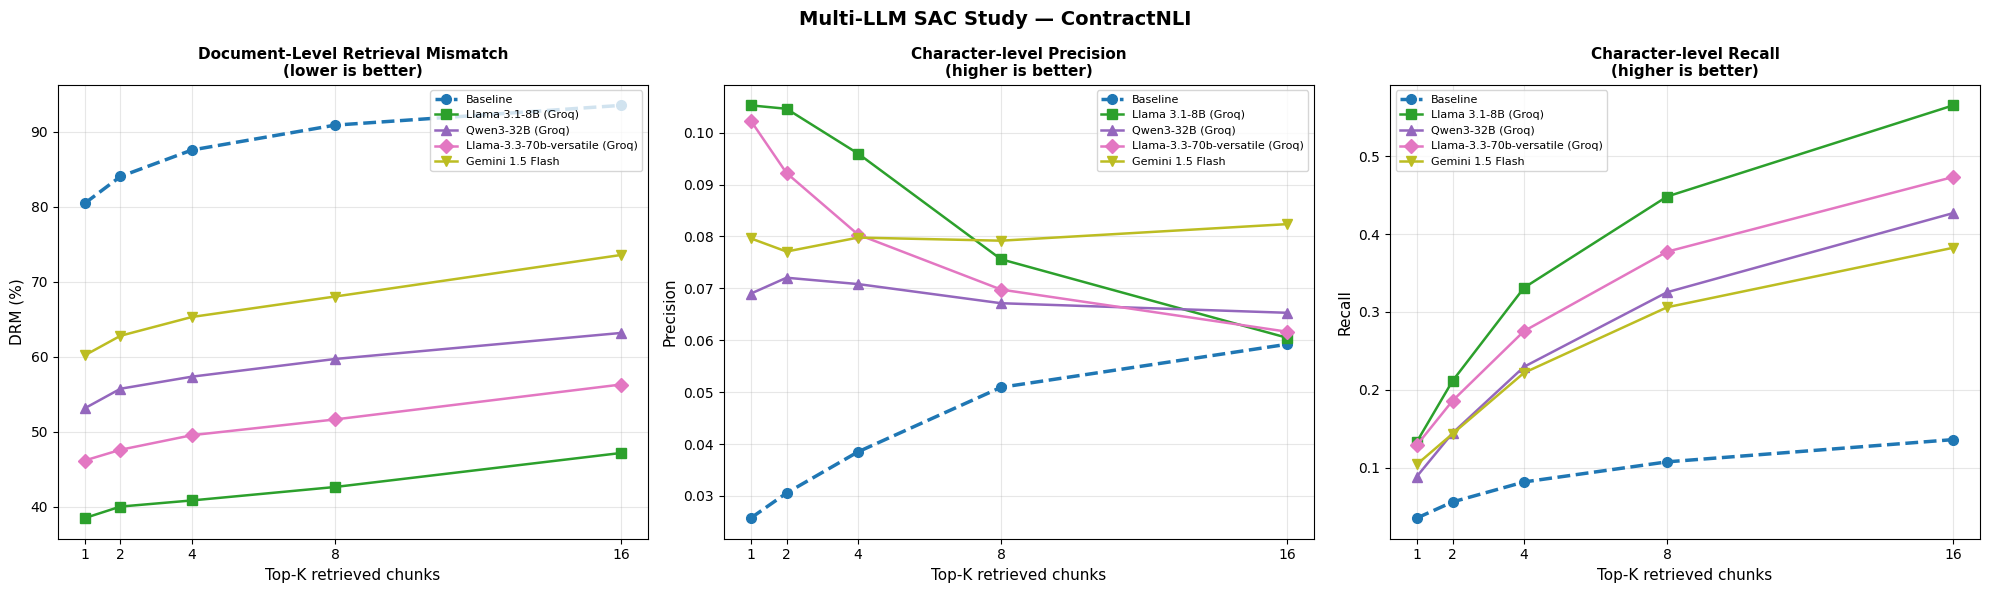

Chart saved to multi_llm_results.png


In [19]:
# ── Plots ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

k_values     = [1, 2, 4, 8, 16]
method_names = list(all_results.keys())
colours      = plt.cm.tab10(np.linspace(0, 0.8, len(method_names)))
markers      = ["o", "s", "^", "D", "v"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Multi-LLM SAC Study — ContractNLI",
             fontsize=14, fontweight="bold")

panels = [
    ("drm",       "DRM (%)",   axes[0], "Document-Level Retrieval Mismatch\n(lower is better)"),
    ("precision", "Precision", axes[1], "Character-level Precision\n(higher is better)"),
    ("recall",    "Recall",    axes[2], "Character-level Recall\n(higher is better)"),
]

for metric, ylabel, ax, title in panels:
    for i, name in enumerate(method_names):
        vals = [all_results[name][k][metric] for k in k_values]
        ls   = "--" if name == "Baseline" else "-"
        lw   = 2.5  if name == "Baseline" else 1.8
        ax.plot(k_values, vals,
                marker=markers[i % len(markers)],
                color=colours[i], linewidth=lw,
                linestyle=ls, markersize=7, label=name)
    ax.set_xlabel("Top-K retrieved chunks", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(k_values)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multi_llm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to multi_llm_results.png")